In [ ]:
import os, sys
sys.path.append('../')

# 13 分箱可视化模块 (core.viz.binning_plots)

演示 `hscredit.core.viz.binning_plots` 中的全部公开方法：

| 序号 | 函数 | 用途 |
|------|------|------|
| 1 | `bin_plot` | 特征分箱图（柱状+坏样本率折线） |
| 2 | `corr_plot` | 特征相关性热力图 |
| 3 | `ks_plot` | KS 曲线 + ROC 曲线 |
| 4 | `hist_plot` | 特征分布直方图 |
| 5 | `psi_plot` | PSI 稳定性分析图 |
| 6 | `dataframe_plot` | DataFrame 表格渲染为图片 |
| 7 | `distribution_plot` | 样本按时间分布图 |
| 8 | `bin_trend_plot` | 分箱趋势分析（多面板） |
| 9 | `batch_bin_trend_plot` | 批量分箱趋势分析 |
| 10 | `bin_overdues_plot` | 多逾期口径分箱图 |

**数据**: 使用内置 German Credit 数据集（1000 条 × 21 列）

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hscredit import init_setting
from hscredit.core import viz
from hscredit.utils.datasets import germancredit

init_setting()

# ---------- 加载数据 ----------
df = germancredit()

column_aliases = {
    'duration_in_month': 'duration',
    'age_in_years': 'age',
    'status_of_existing_checking_account': 'checking_status',
    'savings_account_and_bonds': 'savings_status',
    'installment_rate_in_percentage_of_disposable_income': 'installment_commitment',
}
rename_map = {
    source: target_name
    for source, target_name in column_aliases.items()
    if source in df.columns and target_name not in df.columns
}
if rename_map:
    df = df.rename(columns=rename_map)

# 目标变量：class (0=好客户, 1=坏客户)，转为 int 确保数值运算正常
target = 'class'
if target not in df.columns and 'creditability' in df.columns:
    df[target] = (
        df['creditability']
        .replace({'good': 0, 'bad': 1, 'Good': 0, 'Bad': 1})
        .astype(int)
    )

# 数值型特征
num_features = ['duration', 'credit_amount', 'age', 'installment_commitment']
# 类别型特征
cat_features = ['checking_status', 'credit_history', 'purpose', 'savings_status']

required_columns = [target, *num_features, *cat_features]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f'German Credit 数据缺少字段: {missing_columns}')

df[target] = df[target].astype(int)

# 构造模拟预测概率（基于 age 归一化，仅用于 KS/ROC 演示）
df['score'] = df['age'].fillna(df['age'].median())
score_range = df['score'].max() - df['score'].min()
if score_range == 0:
    df['prob'] = 0.5
else:
    df['prob'] = 1 - (df['score'] - df['score'].min()) / score_range

print(f"样本数: {len(df):,}")
print(f"坏样本率: {df[target].mean():.2%}")
print(f"数值特征: {num_features}")
print(f"类别特征: {cat_features}")
df.head(3)

样本数: 1,000
坏样本率: 30.00%
数值特征: ['duration', 'credit_amount', 'age', 'installment_commitment']
类别特征: ['checking_status', 'credit_history', 'purpose', 'savings_status']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,present_employment_since,installment_commitment,personal_status_and_sex,other_debtors_or_guarantors,...,other_installment_plans,housing,number_of_existing_credits_at_this_bank,job,number_of_people_being_liable_to_provide_maintenance_for,telephone,foreign_worker,class,score,prob
0,... < 0 DM,6,critical account/ other credits existing (not at this bank),radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : divorced/separated,none,...,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,0,67,0.1429
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,none,own,1,skilled employee / official,1,none,yes,1,22,0.9464
2,no checking account,12,critical account/ other credits existing (not at this bank),education,2096,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,none,own,1,unskilled - resident,2,none,yes,0,49,0.4643


---
## 1. bin_plot — 特征分箱图

支持两种模式：
- **模式一**：传入原始数据 + 目标变量，自动分箱
- **模式二**：传入已计算的分箱统计表

支持 `horizontal`（横向）和 `vertical`（纵向）两种方向。

### 1.1 数值特征 — 纵向分箱图

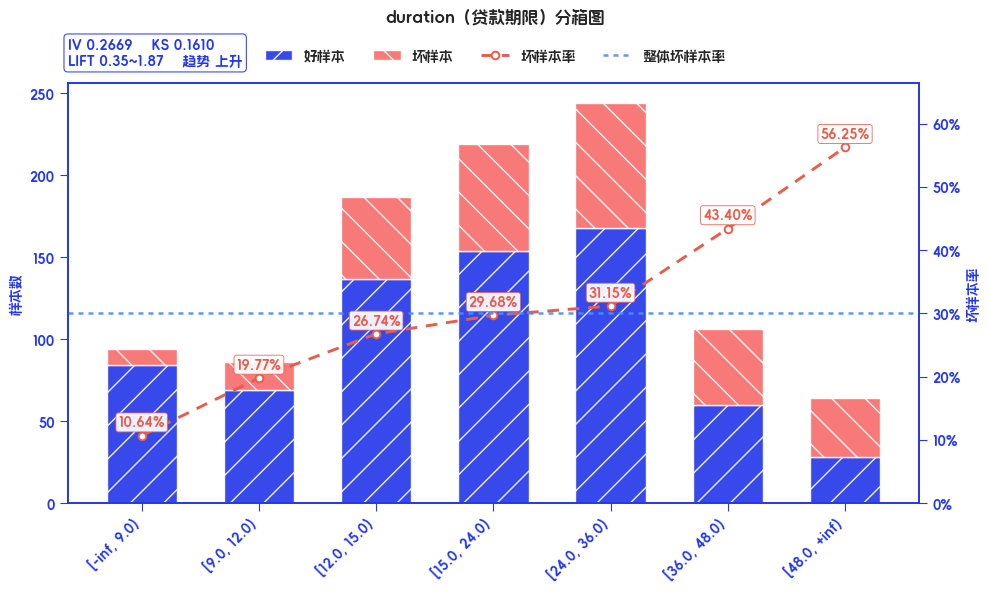

In [3]:
fig = viz.bin_plot(
    df['duration'],
    target=df[target],
    n_bins=8,
    method='quantile',
    title='duration（贷款期限）分箱图',
    orientation='vertical',
    figsize=(10, 6),
)
plt.show()

### 1.2 数值特征 — 横向分箱图

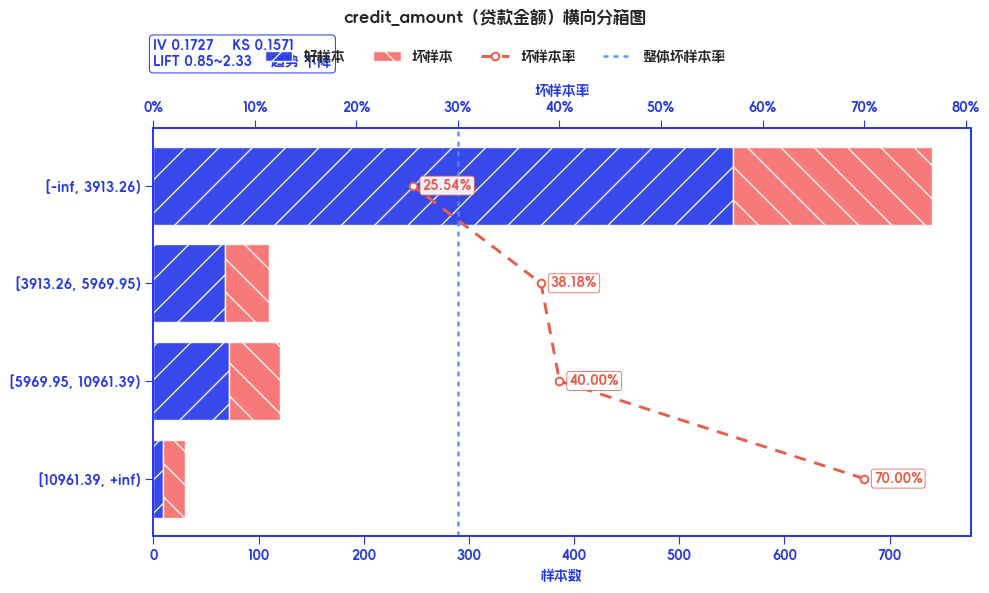

In [4]:
fig = viz.bin_plot(
    df,
    feature='credit_amount',
    target=target,
    n_bins=6,
    method='chi',
    title='credit_amount（贷款金额）横向分箱图',
    orientation='horizontal',
    figsize=(10, 6),
)
plt.show()

### 1.3 类别特征 — 分箱图

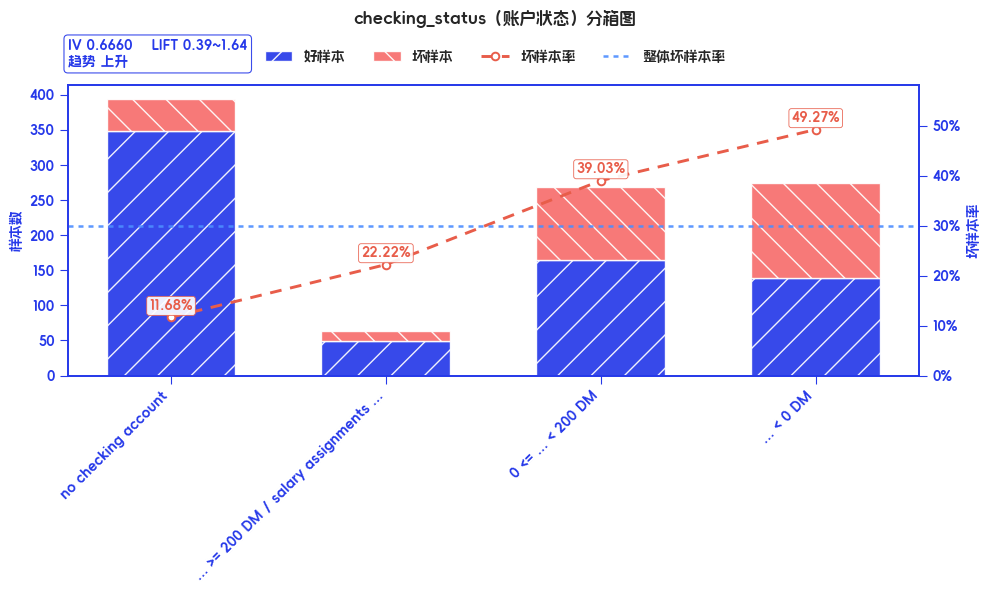

In [5]:
fig = viz.bin_plot(
    df['checking_status'],
    target=df[target],
    method='chi',
    title='checking_status（账户状态）分箱图',
    orientation='vertical',
    figsize=(10, 6),
)
plt.show()

### 1.4 多子图模式（使用 ax 参数）

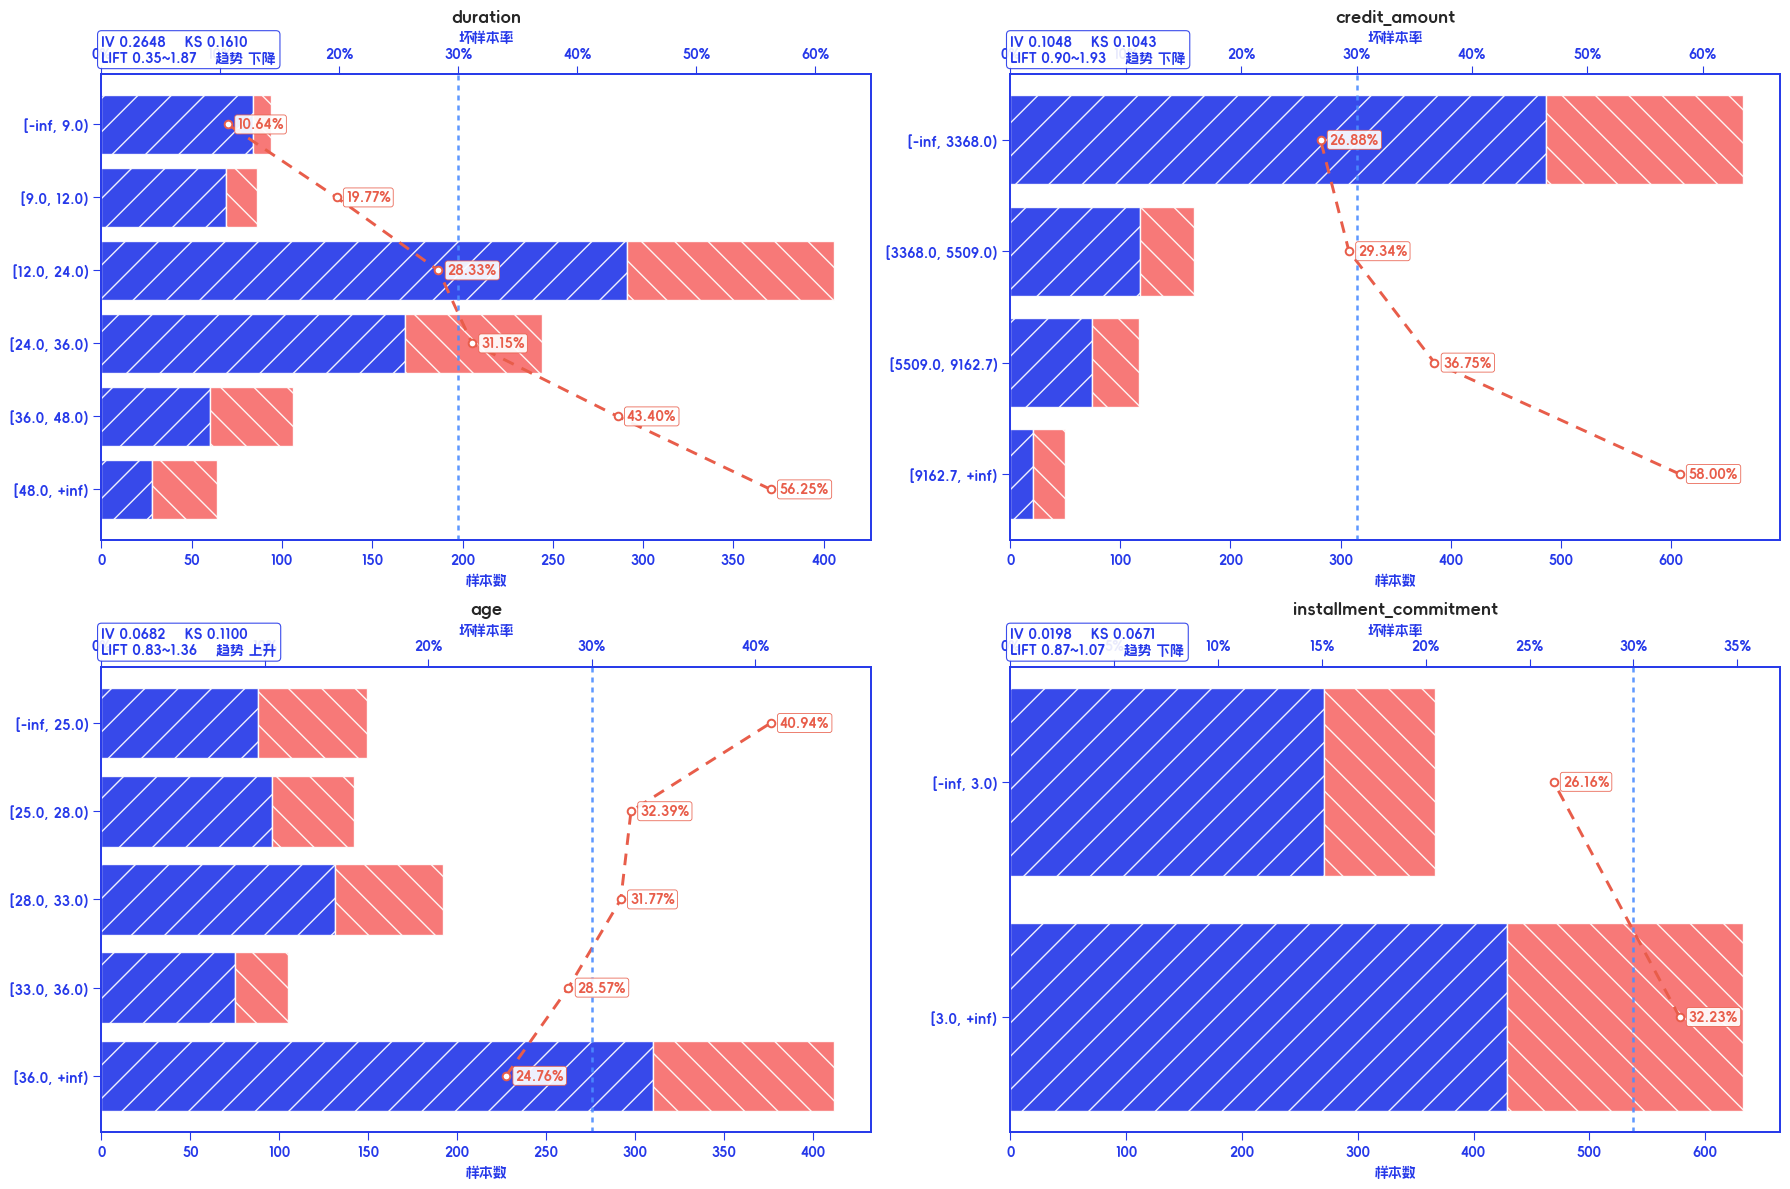

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for i, col in enumerate(num_features):
    row, col_idx = divmod(i, 2)
    viz.bin_plot(
        df[col],
        target=df[target],
        n_bins=6,
        ax=axes[row, col_idx],
        title=col,
    )

plt.tight_layout()
plt.show()

### 1.5 传入分箱统计表（模式二）+ return_frame

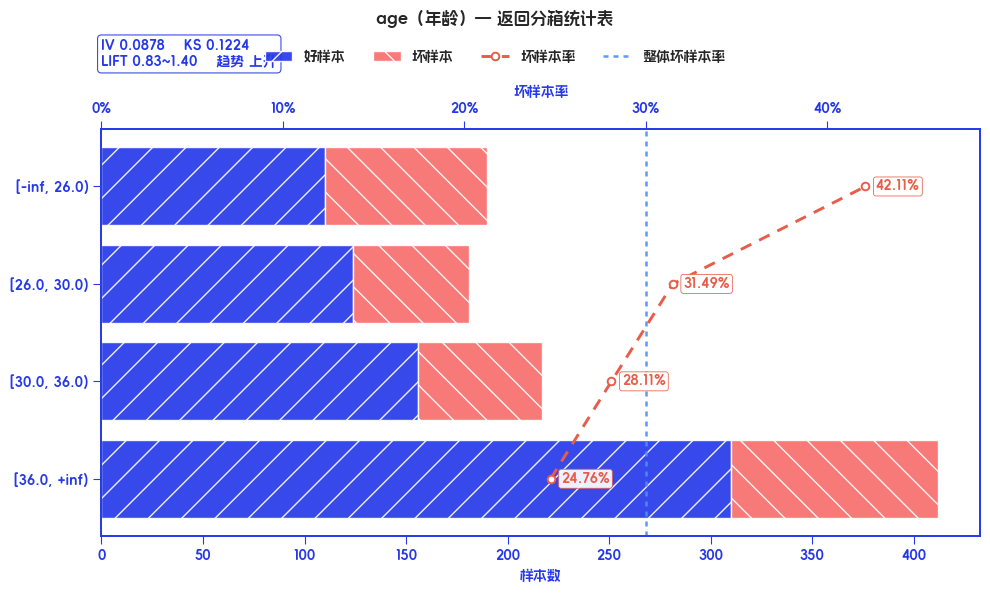

,分箱,分箱标签,样本总数,好样本数,坏样本数,坏样本率,样本占比,指标IV值,分档KS值,LIFT值
0,"[-inf, 26.0)","[-inf, 26.0)",190,110,80,0.4211,0.1900,0.0878,0.1095,1.4035
1,"[26.0, 30.0)","[26.0, 30.0)",181,124,57,0.3149,0.1810,0.0878,0.1224,1.0497
2,"[30.0, 36.0)","[30.0, 36.0)",217,156,61,0.2811,0.2170,0.0878,0.1029,0.9370
3,"[36.0, +inf)","[36.0, +inf)",412,310,102,0.2476,0.4120,0.0878,0.0000,0.8252


In [7]:
# 先获取分箱统计表
fig, frame = viz.bin_plot(
    df['age'],
    target=df[target],
    n_bins=5,
    return_frame=True,
    title='age（年龄）— 返回分箱统计表',
)
plt.show()
frame

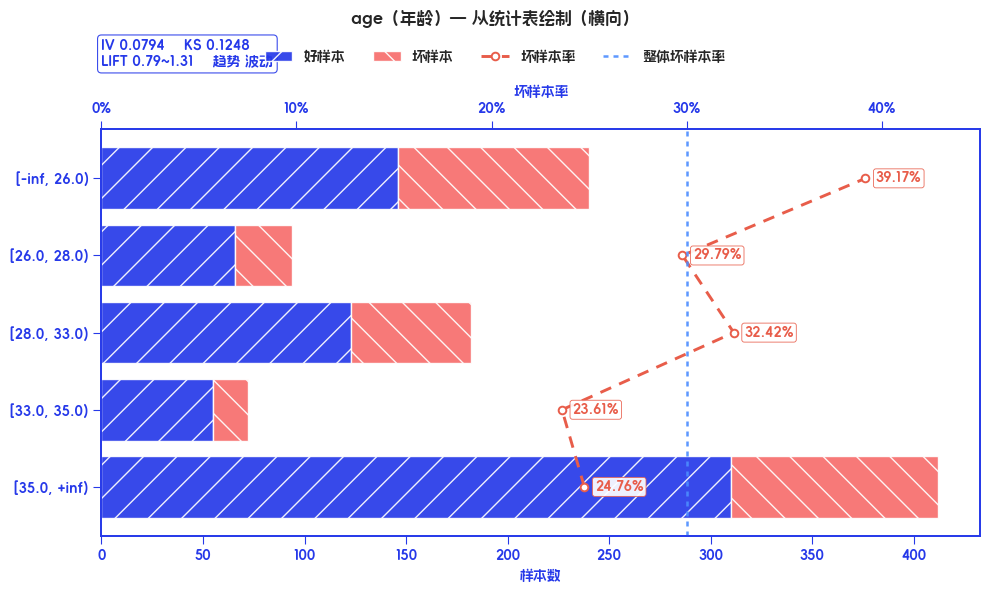

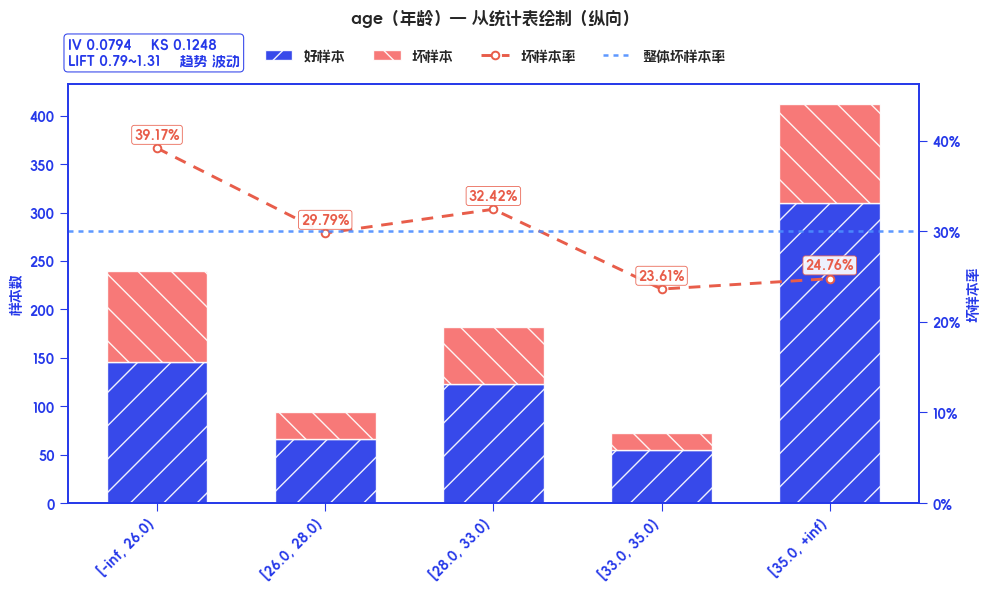

In [8]:
# 使用 feature_bin_stats 生成分箱统计表，再传入 bin_plot
from hscredit.report.feature_analyzer import feature_bin_stats

frame = feature_bin_stats(df, 'age', target=target, method="cart")
fig = viz.bin_plot(frame, title='age（年龄）— 从统计表绘制（横向）', orientation='h')
plt.show()
fig = viz.bin_plot(frame, title='age（年龄）— 从统计表绘制（纵向）', orientation='v')
plt.show()

---
## 2. corr_plot — 特征相关性热力图

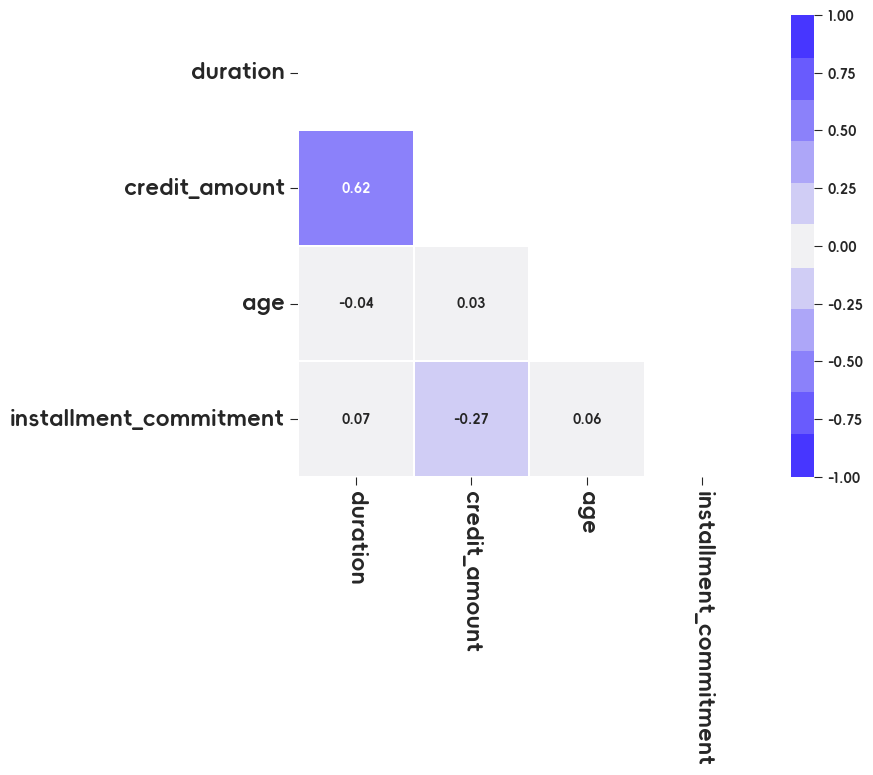

In [9]:
fig = viz.corr_plot(
    df[num_features],
    mask=True,         # 只显示下三角
    figsize=(8, 6),
    annot=True,
    fmt='.2f',
)
plt.show()

---
## 3. ks_plot — KS 曲线 + ROC 曲线

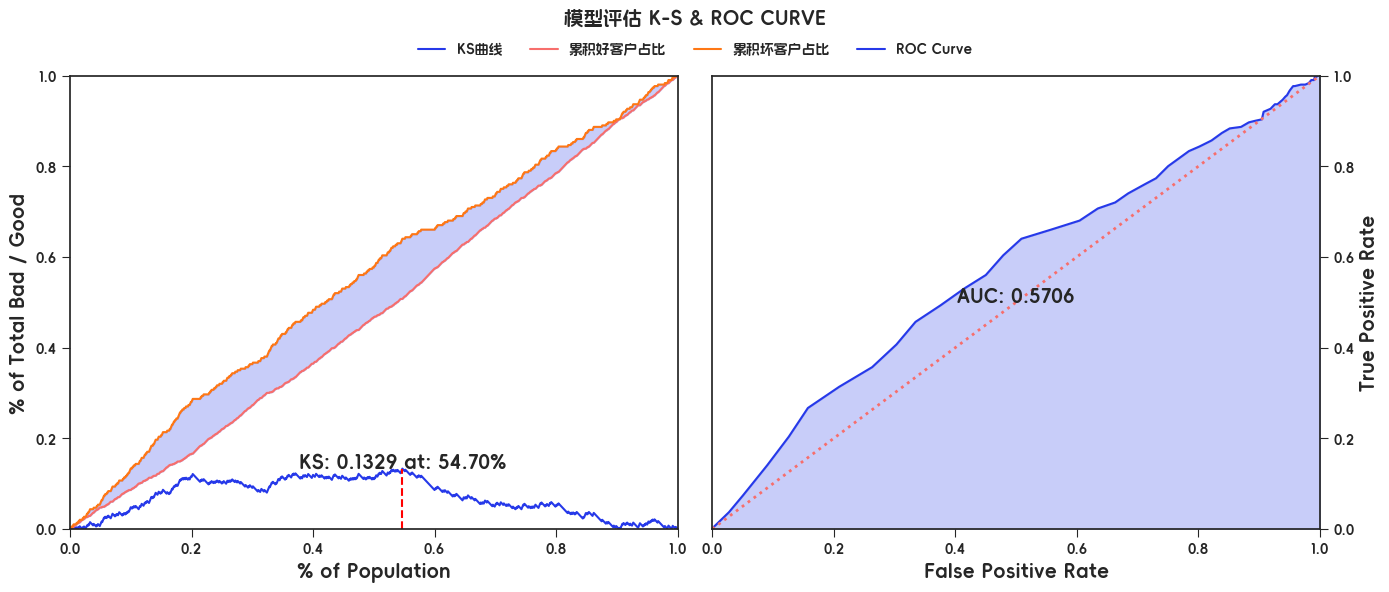

In [10]:
fig = viz.ks_plot(
    df['prob'],
    df[target],
    title='模型评估',
    figsize=(14, 6),
)
plt.show()

---
## 4. hist_plot — 特征分布直方图

### 4.1 按好坏样本分组

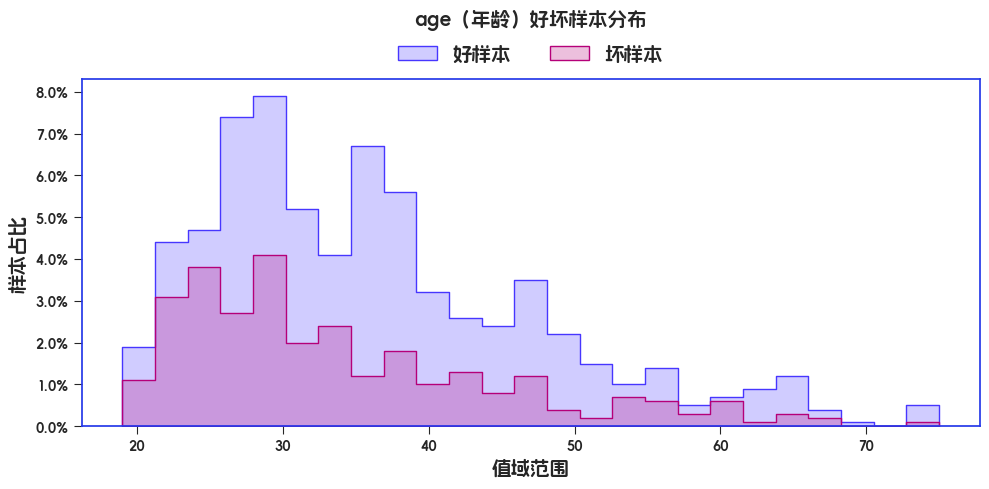

In [11]:
fig = viz.hist_plot(
    df['age'],
    y_true=df[target],
    bins=25,
    title='age（年龄）好坏样本分布',
    figsize=(10, 5),
)
plt.show()

### 4.2 纯分布 + KDE 曲线

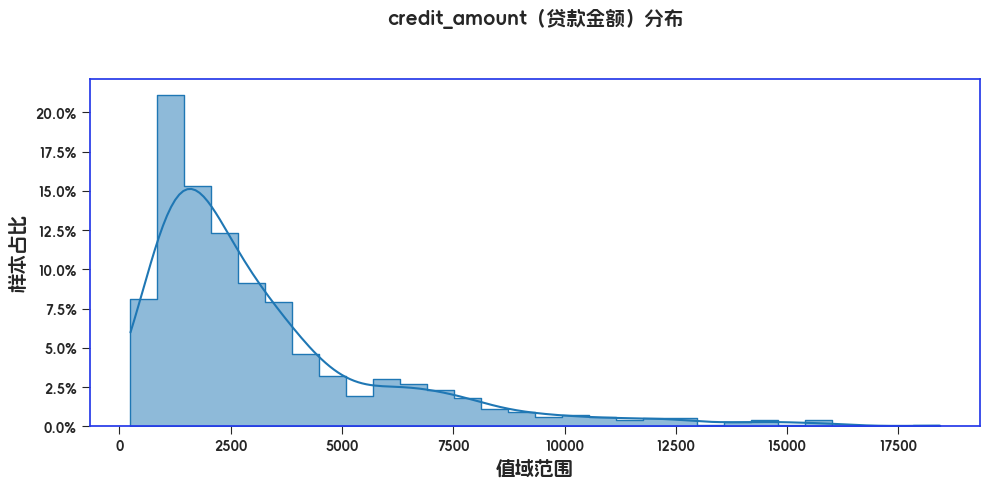

In [24]:
fig = viz.hist_plot(
    df['credit_amount'],
    bins=30,
    kde=True,
    title='credit_amount（贷款金额）分布',
    figsize=(10, 5),
)
plt.show()

---
## 5. psi_plot — PSI 稳定性分析图

对比两个分箱统计表（如跨月对比、训练集 vs 验证集）的样本分布稳定性。

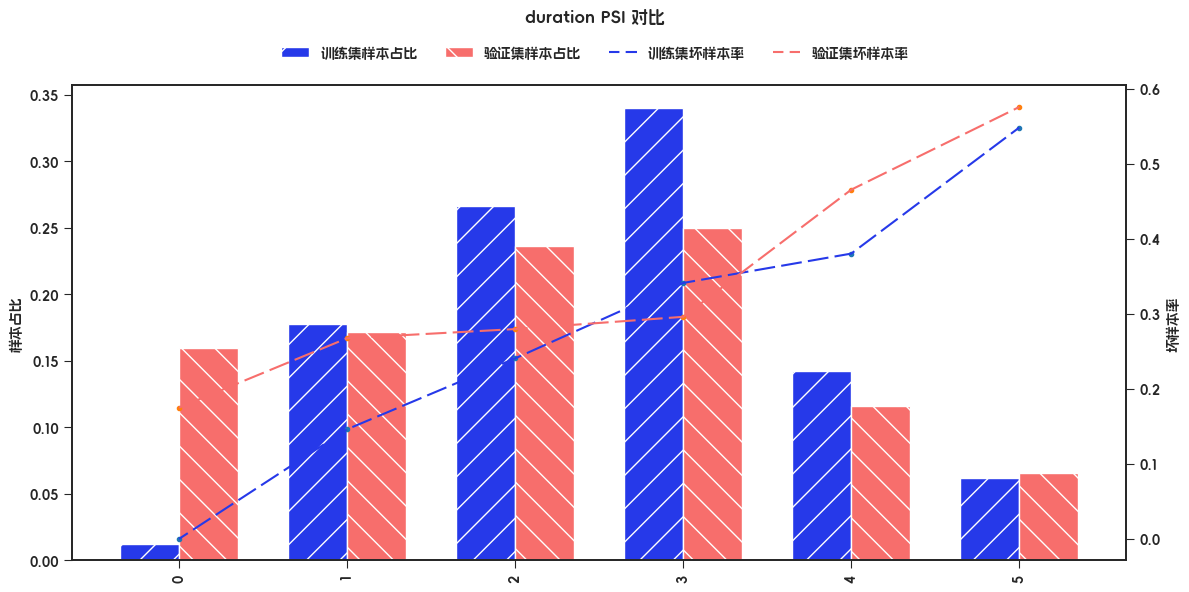

In [13]:
# 模拟两个时期的分箱统计表
from hscredit.core.binning import OptimalBinning

np.random.seed(42)
idx1 = np.random.choice(len(df), 500, replace=False)
idx2 = np.setdiff1d(np.arange(len(df)), idx1)

binner = OptimalBinning(method='quantile', max_n_bins=6)
binner.fit(df.iloc[idx1][['duration']], df.iloc[idx1][target])

expected_table = binner.bin_tables_['duration']

# 用另一批数据生成 actual
binner2 = OptimalBinning(method='quantile', max_n_bins=6)
binner2.fit(df.iloc[idx2][['duration']], df.iloc[idx2][target])
actual_table = binner2.bin_tables_['duration']

fig = viz.psi_plot(
    expected_table,
    actual_table,
    labels=['训练集', '验证集'],
    title='duration PSI 对比',
    figsize=(12, 6),
)
plt.show()

---
## 6. dataframe_plot — DataFrame 表格渲染为图片

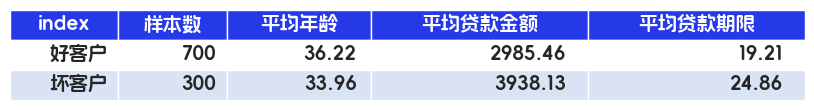

In [14]:
# 取一个小统计表来演示
summary = df.groupby(target).agg(
    样本数=('age', 'count'),
    平均年龄=('age', 'mean'),
    平均贷款金额=('credit_amount', 'mean'),
    平均贷款期限=('duration', 'mean'),
).round(2)
summary.index = ['好客户', '坏客户']

fig = viz.dataframe_plot(
    summary.reset_index(),
    font_size=14,
    header_color='#2639E9',
)
plt.show()

---
## 7. distribution_plot — 样本按时间分布图

展示样本在时间维度上的好/坏客户数量及坏样本率趋势。

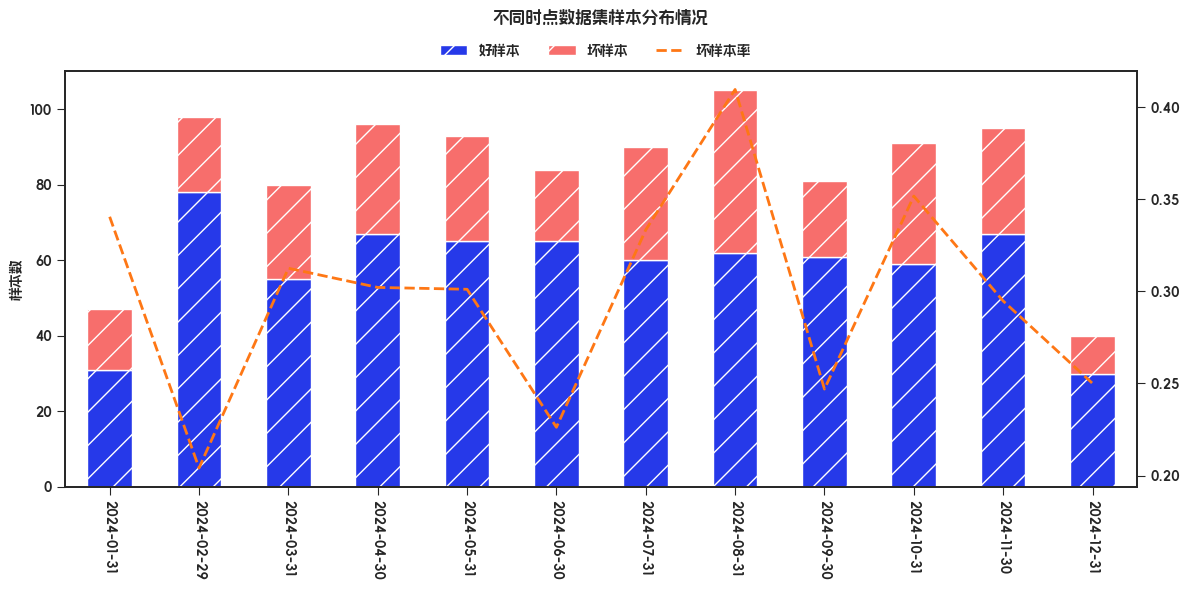

In [15]:
# 模拟日期列（German Credit 无日期，随机生成 12 个月的申请日期）
np.random.seed(42)
df['apply_date'] = pd.date_range('2024-01-01', periods=len(df), freq='8h') + \
    pd.to_timedelta(np.random.randint(0, 30, len(df)), unit='D')

fig = viz.distribution_plot(
    df,
    date='apply_date',
    target=target,
    freq='M',
    figsize=(12, 6),
)
plt.show()

### 7.2 多逾期口径模式

当同时传入 `overdue`（逾期列名列表）和 `dpds`（对应阈值列表）时，`distribution_plot` 以柱状图展示每期样本总量，并叠加多条坏样本率折线，方便对比不同逾期口径的坏率趋势。

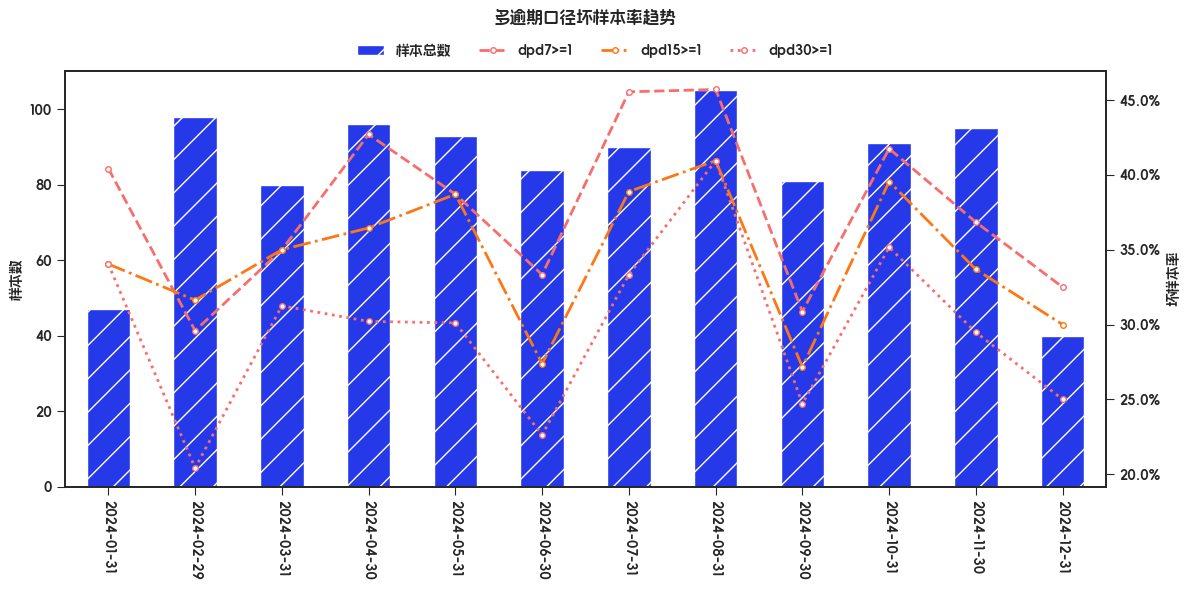

In [16]:
# 模拟多个逾期口径列
np.random.seed(0)
df['dpd7']  = (df[target].values + np.random.binomial(1, 0.10, len(df))).clip(0, 1).astype(int)
df['dpd15'] = (df[target].values + np.random.binomial(1, 0.05, len(df))).clip(0, 1).astype(int)
df['dpd30'] = df[target].values.astype(int)

# 多逾期口径坏样本率趋势
fig = viz.distribution_plot(
    df,
    date='apply_date',
    overdue=['dpd7', 'dpd15', 'dpd30'],
    dpds=[1, 1, 1],
    freq='M',
    figsize=(12, 6),
    title='多逾期口径坏样本率趋势',
)
plt.show()

,日期,样本总数,dpd7>=1_坏样本率,dpd15>=1_坏样本率,dpd30>=1_坏样本率
0,2024-01-31,47,0.4043,0.3404,0.3404
1,2024-02-29,98,0.2959,0.3163,0.2041
2,2024-03-31,80,0.3500,0.3500,0.3125
3,2024-04-30,96,0.4271,0.3646,0.3021
4,2024-05-31,93,0.3871,0.3871,0.3011
5,2024-06-30,84,0.3333,0.2738,0.2262
6,2024-07-31,90,0.4556,0.3889,0.3333
7,2024-08-31,105,0.4571,0.4095,0.4095
8,2024-09-30,81,0.3086,0.2716,0.2469
9,2024-10-31,91,0.4176,0.3956,0.3516


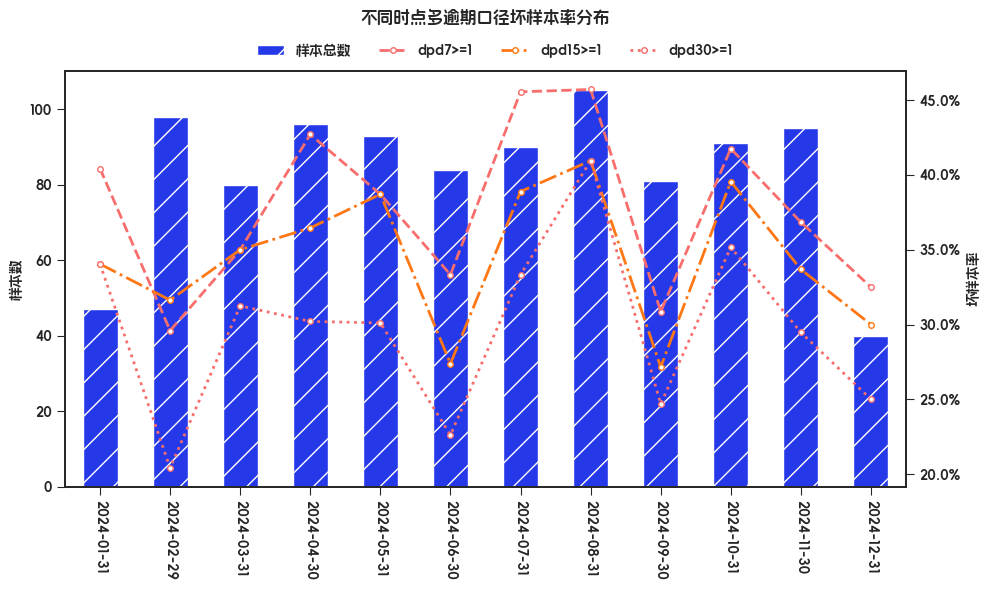

In [17]:
# result=True 返回汇总 DataFrame
result_df = viz.distribution_plot(
    df,
    date='apply_date',
    overdue=['dpd7', 'dpd15', 'dpd30'],
    dpds=[1, 1, 1],
    freq='M',
    result=True,
)
result_df

---
## 8. bin_trend_plot — 分箱趋势分析（多面板）

按时间或维度拆分数据，生成多面板分箱图，直观观察特征在不同维度/时间的表现变化。

### 8.1 按时间维度

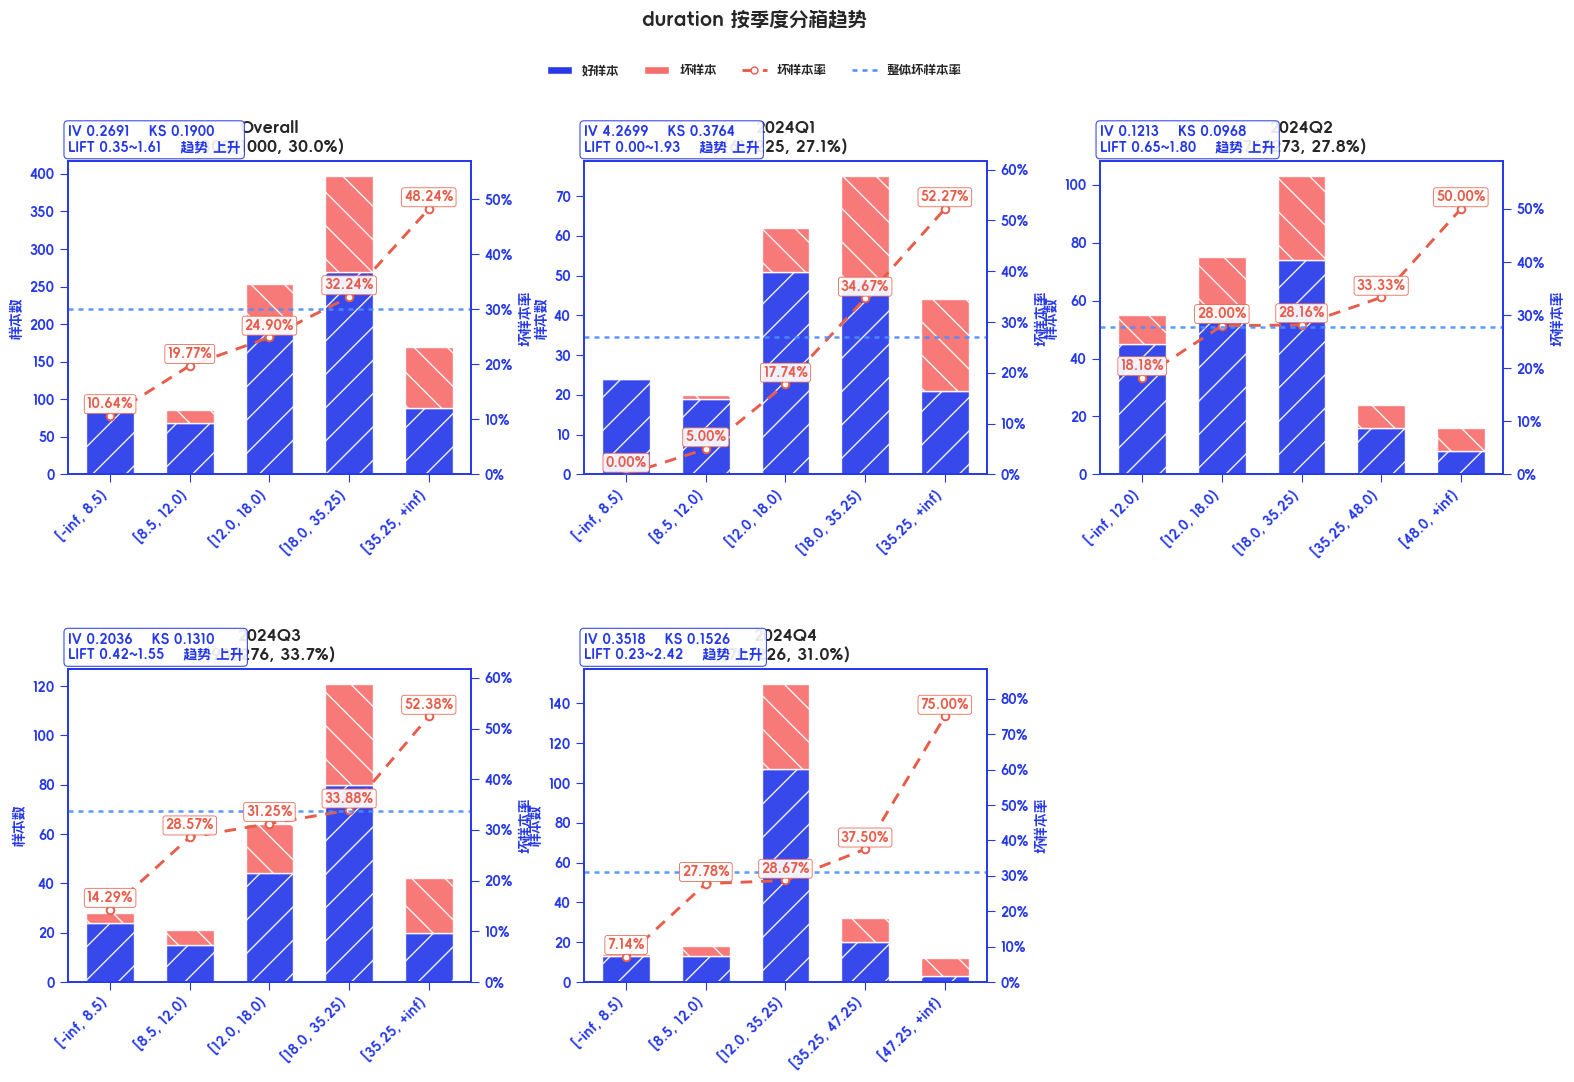

In [18]:
fig = viz.bin_trend_plot(
    df,
    feature='duration',
    target=target,
    date_col='apply_date',
    date_freq='Q',
    max_n_bins=5,
    title='duration 按季度分箱趋势',
)
plt.show()

### 8.2 按类别维度

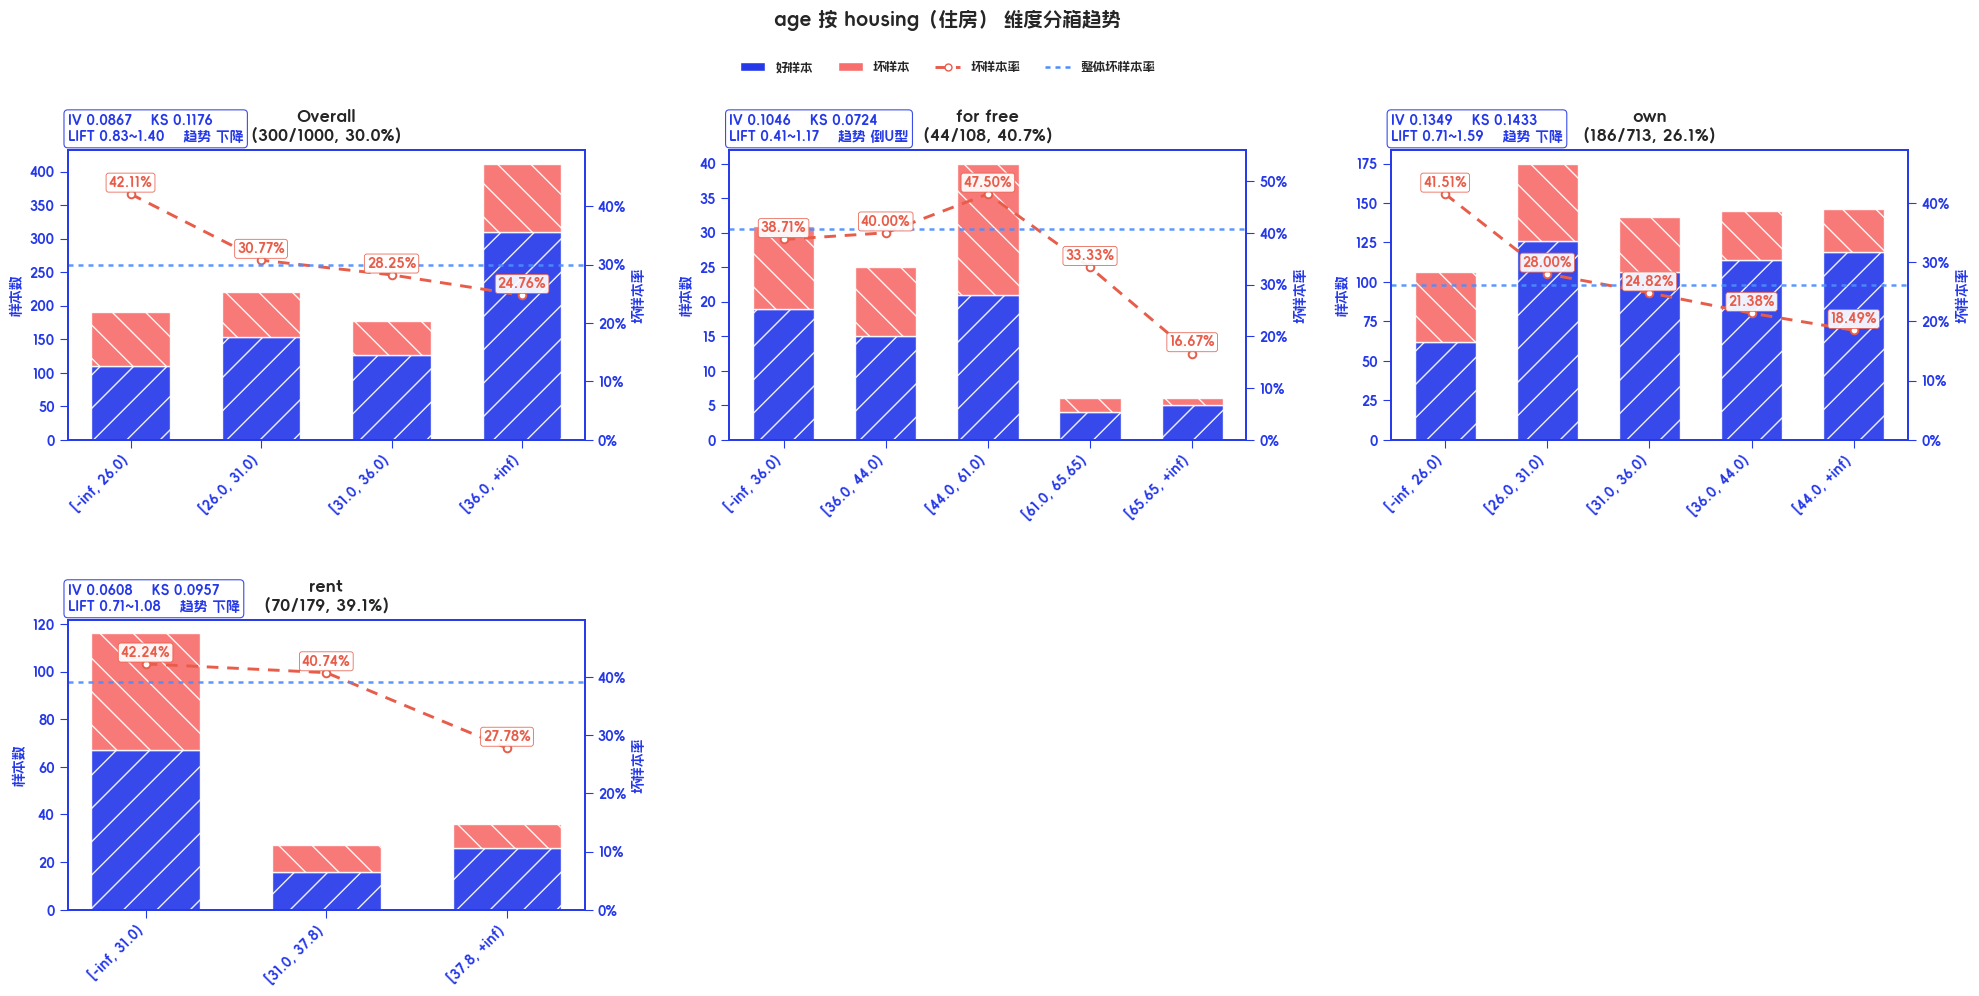

In [19]:
fig = viz.bin_trend_plot(
    df,
    feature='age',
    target=target,
    dimension_cols='housing',
    max_n_bins=5,
    title='age 按 housing（住房） 维度分箱趋势',
    figsize=(20, 10)
)
plt.show()

---
## 9. batch_bin_trend_plot — 批量分箱趋势分析

一次输入多个特征，自动按 IV/KS 排序并逐一绘图。

In [20]:
figs = viz.batch_bin_trend_plot(
    df,
    features=['duration', 'credit_amount', 'age'],
    target=target,
    date_col='apply_date',
    date_freq='Q',
    sort_by='iv',
    max_features=3,
    figsize=(20, 10)
)

for name, fig in figs.items():
    plt.show()

[1/3] Plotting duration...
[2/3] Plotting credit_amount...
[3/3] Plotting age...


---
## 10. bin_overdues_plot — 多逾期口径分箱图

同时查看同一特征在不同逾期定义（如 DPD7 / DPD15 / DPD30）下的分箱表现差异。

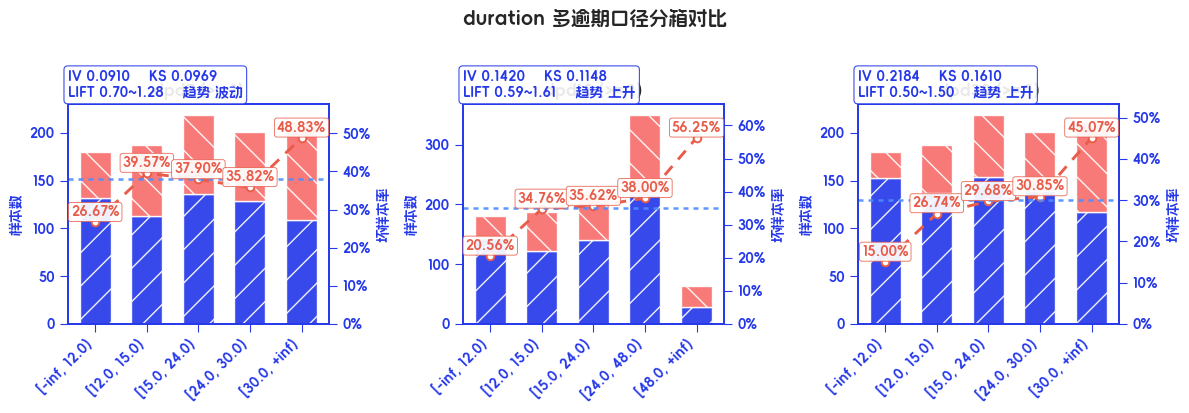

In [21]:
# 模拟多个逾期口径（German Credit 只有一个目标，此处随机模拟 3 个 DPD 列）
np.random.seed(0)
df['dpd7']  = (df[target].values + np.random.binomial(1, 0.10, len(df))).clip(0, 1).astype(int)
df['dpd15'] = (df[target].values + np.random.binomial(1, 0.05, len(df))).clip(0, 1).astype(int)
df['dpd30'] = df[target].values.astype(int)

fig = viz.bin_overdues_plot(
    df,
    feature='duration',
    overdue=['dpd7', 'dpd15', 'dpd30'],
    dpds=[1, 1, 1],
    method='quantile',
    max_n_bins=5,
    title='duration 多逾期口径分箱对比',
)
plt.show()

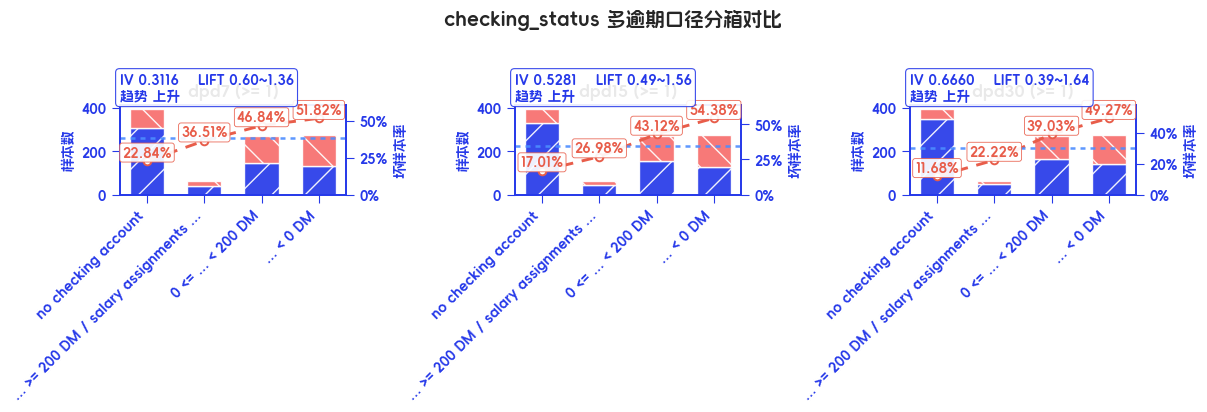

In [22]:
# 类别特征的多逾期口径分箱
fig = viz.bin_overdues_plot(
    df,
    feature='checking_status',
    overdue=['dpd7', 'dpd15', 'dpd30'],
    dpds=[1, 1, 1],
    method='chi',
    title='checking_status 多逾期口径分箱对比',
)
plt.show()

---
## 总结

| 函数 | 场景 | 核心参数 |
|------|------|----------|
| `bin_plot` | 单特征分箱 + 坏样本率 | `orientation`, `method`, `n_bins`, `return_frame`, `ax` |
| `corr_plot` | 特征间相关性 | `mask`, `annot`, `fmt` |
| `ks_plot` | 模型区分度评估 | `score`, `target` |
| `hist_plot` | 特征值分布 | `y_true`, `kde`, `bins` |
| `psi_plot` | 稳定性监控 | `expected`, `actual`, `labels` |
| `dataframe_plot` | 统计表渲染 | `header_color`, `font_size` |
| `distribution_plot` | 样本时间分布 | `date`, `freq` |
| `bin_trend_plot` | 多面板趋势 | `dimension_cols`, `date_col`, `date_freq` |
| `batch_bin_trend_plot` | 批量趋势 | `features`, `sort_by`, `max_features` |
| `bin_overdues_plot` | 多逾期口径 | `overdue`, `dpds` |